In [1]:
!pwd

/users/khordadi/simd-loops


In [2]:
import subprocess
import time
from pathlib import Path


loops_dir = Path("build/neon/standalone/bin/")

loops = []
for file in loops_dir.iterdir():
    if file.is_file():
        loops.append(int(file.stem.split("_")[1]))
loops.sort()
print(f'{len(loops)} loops found.')

REPETITIONS = 1_000_000

selected_loops = []
for id in loops:
    cmd = [f"build/neon/bin/simd_loops", "-k", str(id), "-n", str(REPETITIONS)]
    
    start = time.time()
    output = subprocess.run(cmd, capture_output=True, text=True)
    end = time.time()
    
    if output.returncode != 0:
        print(f"Loop {id} execution failed with error:")
        print(output.stdout)
        continue
        # raise RuntimeError(f"Loop {loop} execution failed.")
    else:
        output = output.stdout.strip()
        output = output.splitlines()
        loop_name = output[0].split(" - ")[1]
        loop_purpose = output[1].split(": ")[1]
        assert output[-1] == " - Checksum correct.", f"Loop {id} failed checksum verification."

    id = (id, loop_name, loop_purpose, end - start)
    print(id)
    selected_loops.append(id)

75 loops found.
(1, 'FP32 inner product', 'Use of fp32 MLA instruction', 0.7282528877258301)
(2, 'UINT32 inner product', 'Use of u32 MLA instruction', 0.7282974720001221)
(3, 'FP64 inner product', 'Use of fp64 MLA instruction', 0.7312309741973877)
(4, 'UINT64 inner product', 'Use of u64 MLA instruction', 1.709930181503296)
(5, 'strlen short strings', 'Use of FF and NF loads instructions', 1.8065757751464844)
(6, 'strlen long strings', 'Use of FF and NF loads instructions', 0.7182304859161377)
(8, 'Precise fp64 add reduction', 'Use of FADDA instructions', 6.058497905731201)
(9, 'Pointer chasing', 'Use of CTERM and BRK instructions', 1.4138972759246826)
(10, 'Conditional reduction (fp)', 'Use of CLAST (SIMD&FP scalar) instructions', 4.205719470977783)
Loop 12 execution failed with error:
Loop 012 - Particle motion
 - Purpose: Use of FP compare instructions
ABORT: No implementations available for this target.

(19, 'Mark objects', 'Use of scatters store instruction', 4.84907603263855)
(22

In [3]:
TARGET_DURATION = 10 # seconds

In [10]:
loops = []
for (id, name, purpose, duration) in selected_loops:
    single_duration = duration / REPETITIONS
    iterations = int(TARGET_DURATION / single_duration)
    print(f"Loop {id} - {iterations} iterations to reach {TARGET_DURATION} seconds")
    loops.append(
        {
            "id": id,
            "name": name,
            "purpose": purpose,
        }
        )

import json
with open(f'loops.metadata.json', "w") as f:
    json.dump(loops, f, indent=1)

Loop 1 - 13731493 iterations to reach 10 seconds
Loop 2 - 13730653 iterations to reach 10 seconds
Loop 3 - 13675569 iterations to reach 10 seconds
Loop 4 - 5848191 iterations to reach 10 seconds
Loop 5 - 5535333 iterations to reach 10 seconds
Loop 6 - 13923107 iterations to reach 10 seconds
Loop 8 - 1650574 iterations to reach 10 seconds
Loop 9 - 7072649 iterations to reach 10 seconds
Loop 10 - 2377714 iterations to reach 10 seconds
Loop 19 - 2062248 iterations to reach 10 seconds
Loop 22 - 17331340 iterations to reach 10 seconds
Loop 23 - 7442067 iterations to reach 10 seconds
Loop 24 - 13182790 iterations to reach 10 seconds
Loop 25 - 17673823 iterations to reach 10 seconds
Loop 26 - 7714288 iterations to reach 10 seconds
Loop 27 - 3753611 iterations to reach 10 seconds
Loop 28 - 1897249 iterations to reach 10 seconds
Loop 29 - 5419286 iterations to reach 10 seconds
Loop 31 - 24298114 iterations to reach 10 seconds
Loop 32 - 16081023 iterations to reach 10 seconds
Loop 33 - 11299748 

In [ ]:
modes = ["neon", "sve", "sve2"]
lines = []
for mode in modes:
    lines.append(f'#!/bin/bash')
    lines.append(f'\n')

    for loop in loops:
        id = loop["id"]
        name = loop["name"]
        iterations = loop["iterations"]
        purpose = loop["purpose"]
        
        lines.append(f'echo id={id}')
        lines.append(f'echo mode={mode}')
        lines.append(f'echo iterations={iterations}')
        lines.append(f'echo start=$(date +%s.%N)')
        lines.append(f'./build/{mode}/bin/simd_loops -k {id} -n {iterations} > /dev/null 2>&1')
        lines.append(f'echo code=$?')
        lines.append(f'echo end=$(date +%s.%N)')
        lines.append(f'echo')
        lines.append(f'\n')

with open(f'run.sh', "w") as f:            
    f.writelines(line + "\n" for line in lines)

!cat run.sh

#!/bin/bash


echo id=1
echo mode=neon
echo iterations=13731493
echo start=$(date +%s.%N)
./build/neon/bin/simd_loops -k 1 -n 13731493 > /dev/null 2>&1
echo code=$?
echo end=$(date +%s.%N)
echo


echo id=2
echo mode=neon
echo iterations=13730653
echo start=$(date +%s.%N)
./build/neon/bin/simd_loops -k 2 -n 13730653 > /dev/null 2>&1
echo code=$?
echo end=$(date +%s.%N)
echo


echo id=3
echo mode=neon
echo iterations=13675569
echo start=$(date +%s.%N)
./build/neon/bin/simd_loops -k 3 -n 13675569 > /dev/null 2>&1
echo code=$?
echo end=$(date +%s.%N)
echo


echo id=4
echo mode=neon
echo iterations=5848191
echo start=$(date +%s.%N)
./build/neon/bin/simd_loops -k 4 -n 5848191 > /dev/null 2>&1
echo code=$?
echo end=$(date +%s.%N)
echo


echo id=5
echo mode=neon
echo iterations=5535333
echo start=$(date +%s.%N)
./build/neon/bin/simd_loops -k 5 -n 5535333 > /dev/null 2>&1
echo code=$?
echo end=$(date +%s.%N)
echo


echo id=6
echo mode=neon
echo iterations=13923107
echo start=$(date +%s.%N)
./bu

In [46]:
import pandas as pd


def machine_name(machine):
    if machine == "apple":
        return "Apple M4 Pro"
    elif machine == "google":
        return "Google Axion"
    elif machine == "nvidia":
        return "NVIDIA GH200"
    else:
        return machine
    
def mode_name(mode):
    if mode == "neon":
        return "NEON"
    elif mode == "sve":
        return "SVE"
    elif mode == "sve2":
        return "SVE2"
    else:
        return mode
    
def loops_name(id):
    for loop in loops:
        if loop["id"] == id:
            return loop["name"]
    return None

machines = [
    "apple", 
    "google",
    "nvidia"
]
    
modes = ["neon", "sve", "sve2"]

data = []
for machine in machines:    
    print(f"[machine] {machine}")
    with open(f"profiles/{machine}.txt", "r") as f:
            lines = f.readlines()
            lines = [line.strip() for line in lines if line.strip()]
    
    i = 0
    while i < len(lines):
        assert lines[i].startswith("id="), f"Expected line starting with 'id=' but got: {lines[i]}"
        id = int(lines[i].split("=")[1])
        i += 1
        
        assert lines[i].startswith("mode="), f"Expected line starting with 'mode=' but got: {lines[i]}"
        mode = lines[i].split("=")[1]
        i += 1
        
        assert lines[i].startswith("iterations="), f"Expected line starting with 'iterations=' but got: {lines[i]}"
        iterations = int(lines[i].split("=")[1])
        i += 1
        
        assert lines[i].startswith("start="), f"Expected line starting with 'start=' but got: {lines[i]}"
        start = float(lines[i].split("=")[1])
        i += 1

        assert lines[i].startswith("code="), f"Expected line starting with 'code=' but got: {lines[i]}"
        code = int(lines[i].split("=")[1])
        i += 1

        assert lines[i].startswith("end="), f"Expected line starting with 'end=' but got: {lines[i]}"
        end = float(lines[i].split("=")[1])
        i += 1
        
        duration = end - start if code == 0 else None

        data.append((machine, mode, id, iterations, duration))

df = pd.DataFrame(data, columns=["machine", "mode", "id", "iterations", "duration"])
df

[machine] apple
[machine] google
[machine] nvidia


,machine,mode,id,iterations,duration
0,apple,neon,1,13731493,7.158543
1,apple,neon,2,13730653,5.854441
2,apple,neon,3,13675569,7.368505
3,apple,neon,4,5848191,3.264801
4,apple,neon,5,5535333,6.883615
...,...,...,...,...,...
535,nvidia,sve2,221,30815636,10.868189
536,nvidia,sve2,222,656844,10.033943
537,nvidia,sve2,223,3320413,9.408786
538,nvidia,sve2,231,15424896,10.200953


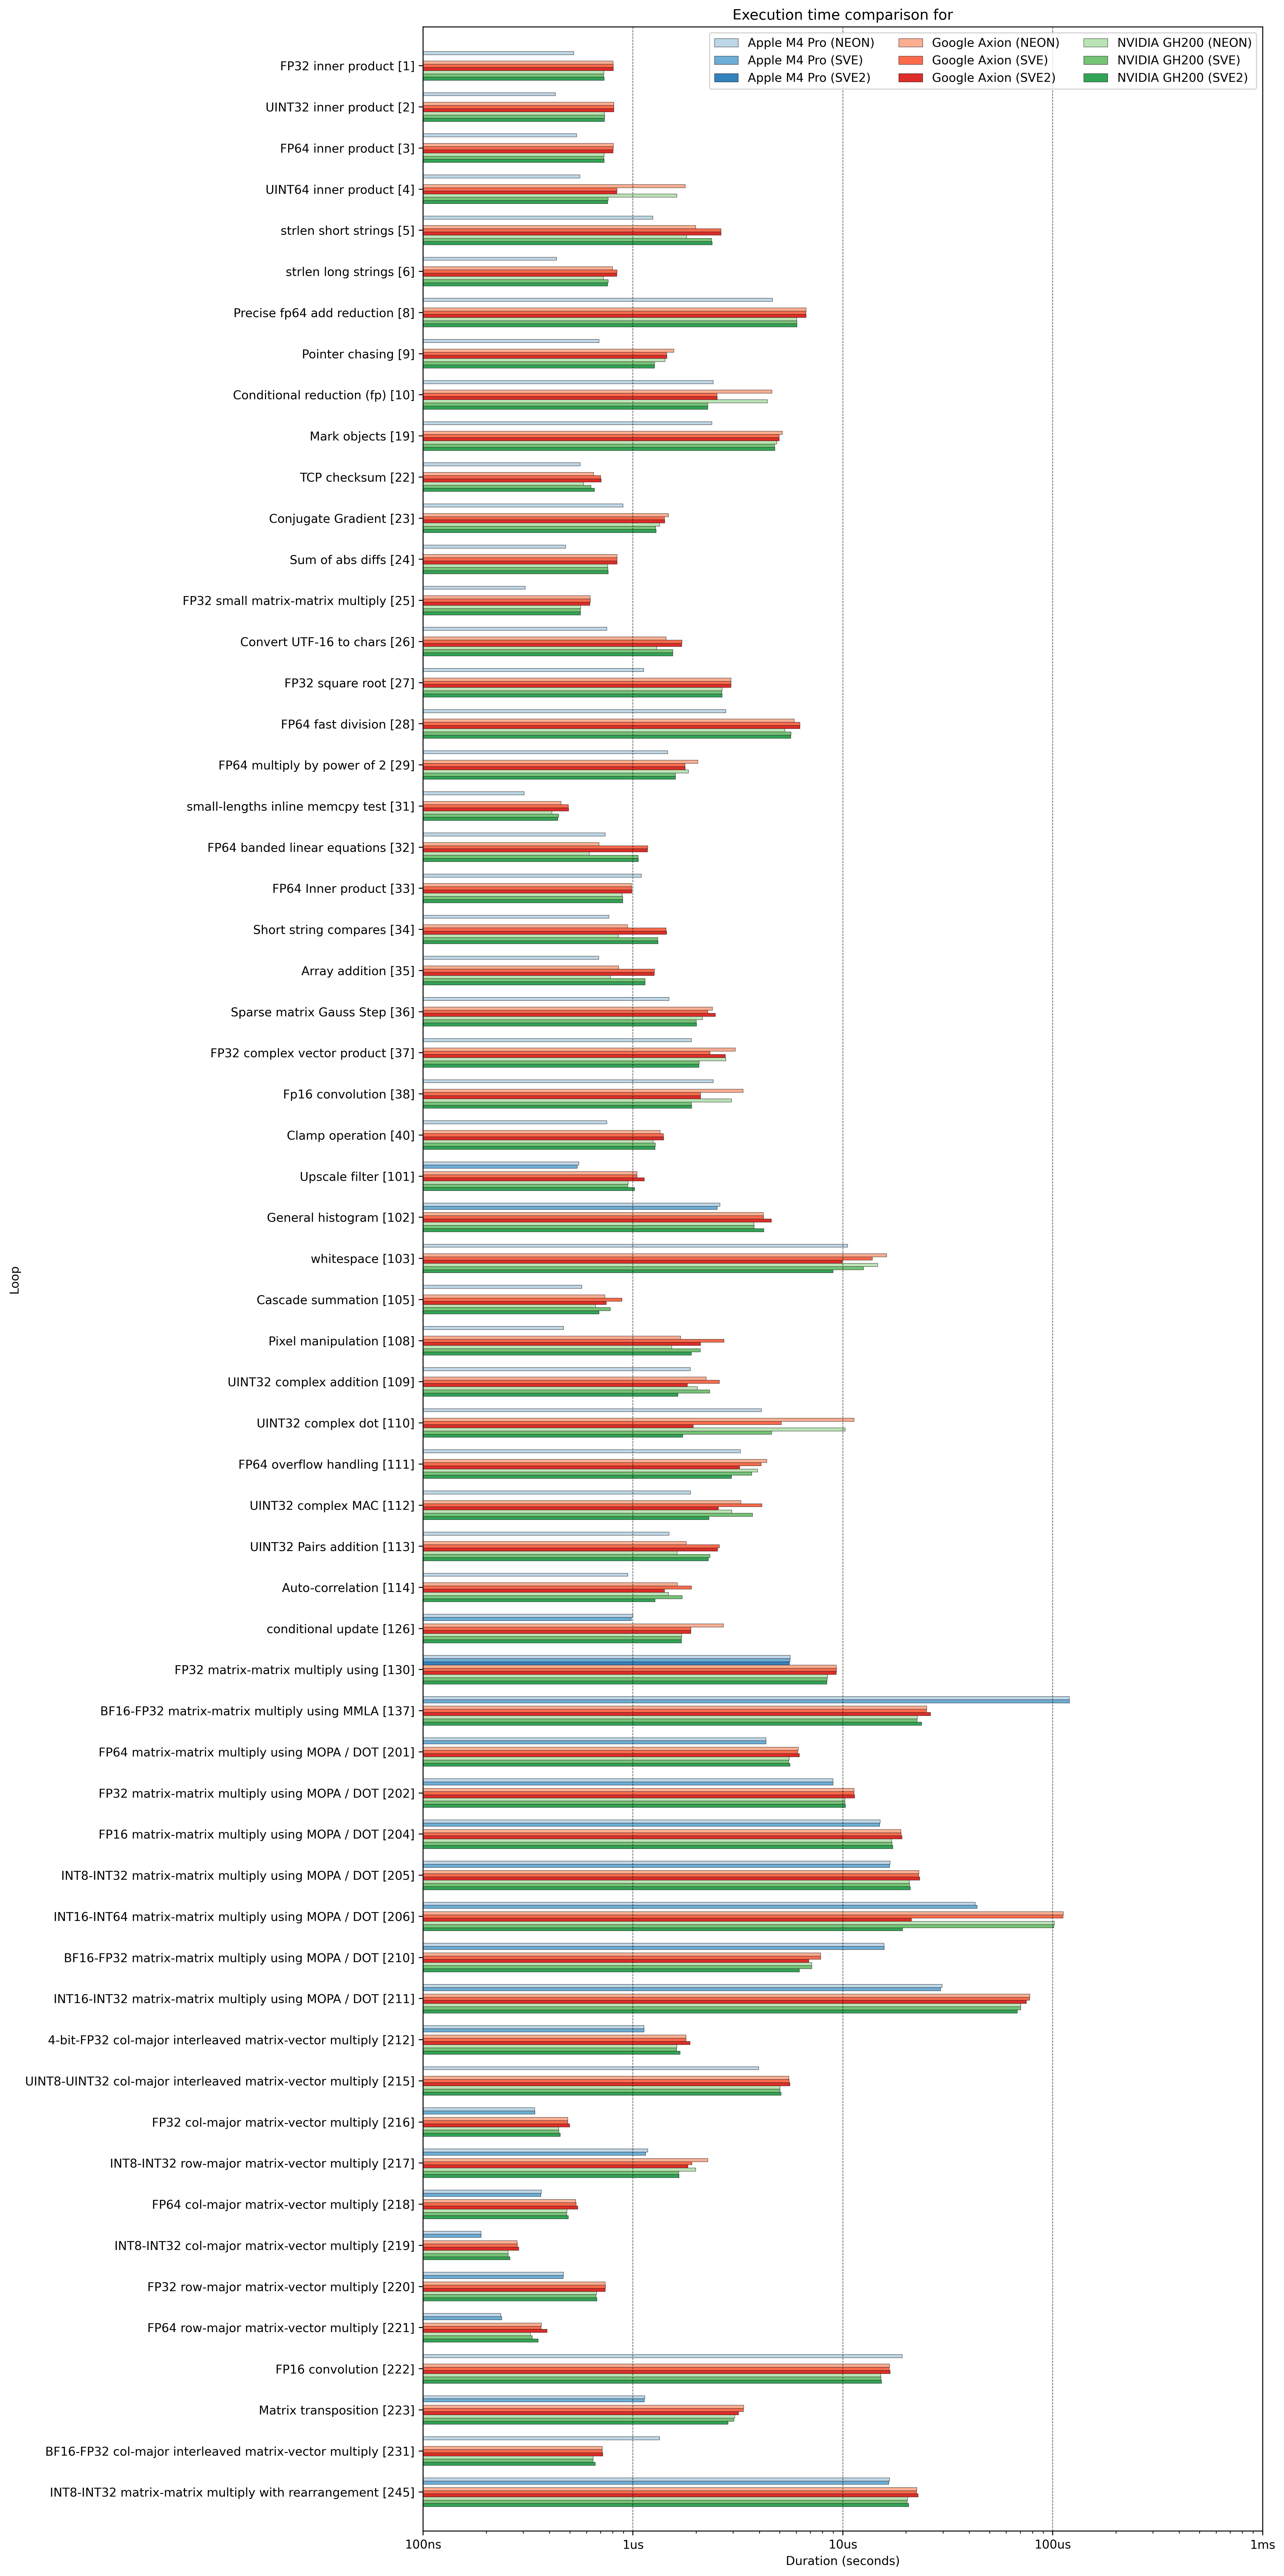

In [70]:
from bokeh import palettes

colors = []
colors.extend(palettes.Blues5[1:-1][::-1])
colors.extend(palettes.Reds5[1:-1][::-1])
colors.extend(palettes.Greens5[1:-1][::-1])

bars = []
for machine in machines:
    for mode in modes:
        subset = df[(df["machine"] == machine) & (df["mode"] == mode)]
        bars.append(
            {
                "machine": machine,
                "mode": mode,
                "ids": subset["id"].tolist(),
                "iterations": subset["iterations"].tolist(),
                "durations": subset["duration"].tolist()
            }
        )
        
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,30), dpi=320)
n = len(bars)
bar_width = 0.7 / n
xs = np.arange(len(bars[0]["ids"]))

for i, bar in enumerate(bars):
    durations = [
        duration / iterations
        for duration, iterations in zip(bar["durations"], bar["iterations"])
    ]

    offset = (i - (n - 1) / 2 + 1) * bar_width

    plt.barh(
        xs + offset,
        durations,
        height=bar_width,
        label=f'{machine_name(bar["machine"])} ({mode_name(bar["mode"])})',
        color=colors[i],
        edgecolor="black",
        linewidth=0.25
    )
    
# make x log
plt.xscale("log")

plt.xlabel("Duration (seconds)")
plt.ylabel("Loop")

# revert y-axis to have the highest loop ID at the top
plt.gca().invert_yaxis()

# write the loop name on the y-axis
plt.yticks(np.arange(len(bars[0]["ids"])) + bar_width, [f'{loops_name(id)} [{id}]' for id in bars[0]["ids"]])

# write 0.01, 0.1, 1, 10 on the x-axis
plt.xticks([1e-7, 1e-6, 1e-5, 1e-4, 1e-3], ["100ns", "1us", "10us", "100us", "1ms"])

# y margin to 0.1
plt.margins(y=0.01)


# set x grid
plt.grid(axis="x", which="major", linestyle="--", linewidth=0.5, color="black", alpha=0.7)


plt.title("Execution time comparison for")
plt.legend(ncol=3, loc="upper right")



plt.tight_layout()
# plt.savefig("loop_durations.png")
plt.show()